In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
#reading dataset
df=pd.read_csv("Sales.csv")
print(df)

     order_id        date        item_name  item_type  item_price  quantity  \
0           1  07-03-2022         Aalopuri   Fastfood          20        13   
1           2   8/23/2022          Vadapav   Fastfood          20        15   
2           3  11/20/2022          Vadapav   Fastfood          20         1   
3           4  02-03-2023  Sugarcane juice  Beverages          25         6   
4           5  10-02-2022  Sugarcane juice  Beverages          25         8   
..        ...         ...              ...        ...         ...       ...   
995       996   3/19/2023          Frankie   Fastfood          50        10   
996       997   9/20/2022         Sandwich   Fastfood          60         7   
997       998   1/26/2023         Sandwich   Fastfood          60        13   
998       999   8/27/2022         Panipuri   Fastfood          20         5   
999      1000   5/29/2022         Aalopuri   Fastfood          20         3   

     transaction_amount transaction_type received_b

In [6]:
df=pd.read_csv("Sales.csv")
df

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening
...,...,...,...,...,...,...,...,...,...,...
995,996,3/19/2023,Frankie,Fastfood,50,10,500,NaN,Mrs.,Evening
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,NaN,Mr.,Evening
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,NaN,Mr.,Evening
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,NaN,Mrs.,Afternoon


In [7]:
#find info of dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   order_id            1000 non-null   int64
 1   date                1000 non-null   str  
 2   item_name           1000 non-null   str  
 3   item_type           1000 non-null   str  
 4   item_price          1000 non-null   int64
 5   quantity            1000 non-null   int64
 6   transaction_amount  1000 non-null   int64
 7   transaction_type    893 non-null    str  
 8   received_by         1000 non-null   str  
 9   time_of_sale        1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB


In [8]:
# Find the stastical information for integer columns
df.describe()

,order_id,item_price,quantity,transaction_amount
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,33.315000,8.162000,275.230000
std,288.819436,14.921744,4.413075,204.402979
min,1.000000,20.000000,1.000000,20.000000
25%,250.750000,20.000000,4.000000,120.000000
50%,500.500000,25.000000,8.000000,240.000000
75%,750.250000,50.000000,12.000000,360.000000
max,1000.000000,60.000000,15.000000,900.000000


In [9]:
# Find the stastical information for string columns
df.describe(include = "str")

,date,item_name,item_type,transaction_type,received_by,time_of_sale
count,1000,1000,1000,893,1000,1000
unique,348,7,2,2,2,5
top,8/31/2022,Cold coffee,Fastfood,Cash,Mr.,Night
freq,8,161,686,476,512,205


In [10]:
#access column data - for a single column
df['item_name']

0             Aalopuri
1              Vadapav
2              Vadapav
3      Sugarcane juice
4      Sugarcane juice
            ...       
995            Frankie
996           Sandwich
997           Sandwich
998           Panipuri
999           Aalopuri
Name: item_name, Length: 1000, dtype: str

In [11]:
#access column data - for a multiple columns
df[['item_name','item_type', 'transaction_type']]

,item_name,item_type,transaction_type
0,Aalopuri,Fastfood,NaN
1,Vadapav,Fastfood,Cash
2,Vadapav,Fastfood,Cash
3,Sugarcane juice,Beverages,Online
4,Sugarcane juice,Beverages,Online
...,...,...,...
995,Frankie,Fastfood,NaN
996,Sandwich,Fastfood,NaN
997,Sandwich,Fastfood,NaN
998,Panipuri,Fastfood,NaN


In [12]:
#to find the unique values in column
df['item_name'].unique()

<StringArray>
[       'Aalopuri',         'Vadapav', 'Sugarcane juice',        'Panipuri',
         'Frankie',        'Sandwich',     'Cold coffee']
Length: 7, dtype: str

In [13]:
#to find the unique values in column
df['item_name'].value_counts(())

item_name
Cold coffee        161
Sugarcane juice    153
Panipuri           150
Frankie            139
Aalopuri           134
Vadapav            134
Sandwich           129
Name: count, dtype: int64

In [14]:
df['transaction_type'].unique()

<StringArray>
[nan, 'Cash', 'Online']
Length: 3, dtype: str

In [15]:
df['transaction_type'].value_counts(())

transaction_type
Cash      476
Online    417
Name: count, dtype: int64

In [16]:
df['time_of_sale'].unique()

<StringArray>
['Night', 'Afternoon', 'Evening', 'Morning', 'Midnight']
Length: 5, dtype: str

In [17]:
df['time_of_sale'].value_counts(())

time_of_sale
Night        205
Afternoon    205
Evening      201
Midnight     199
Morning      190
Name: count, dtype: int64

In [18]:
# Handling the missing values
df.isnull()

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,True,False,False
996,False,False,False,False,False,False,False,True,False,False
997,False,False,False,False,False,False,False,True,False,False
998,False,False,False,False,False,False,False,True,False,False


In [19]:
#count the null values in each column
df.isnull().sum()

order_id                0
date                    0
item_name               0
item_type               0
item_price              0
quantity                0
transaction_amount      0
transaction_type      107
received_by             0
time_of_sale            0
dtype: int64

In [20]:
df['transaction_type'].mode()

0    Cash
Name: transaction_type, dtype: str

In [21]:
# handling transaction_type column missing values
df['transaction_type'] = df['transaction_type'].fillna('Cash')

In [22]:
df['transaction_type'].isnull().sum()


np.int64(0)

In [23]:
#device columns into categeorical and numerical
categorical_columns = ['date','item_name','item_type','transaction_type','received_by','time_of_sale']
numerical_columns = ['order_id','item_price', 'quantity', 'transaction_amount']
df.columns

Index(['order_id', 'date', 'item_name', 'item_type', 'item_price', 'quantity',
       'transaction_amount', 'transaction_type', 'received_by',
       'time_of_sale'],
      dtype='str')

In [24]:
df.drop(['order_id', 'date'],axis = 1,inplace = True)  #axis = 1 for vertical 0 for horizontal
df.head()

,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,Aalopuri,Fastfood,20,13,260,Cash,Mr.,Night
1,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening


In [25]:
#Data Transformation
categorical_columns = ['item_name','item_type','transaction_type','received_by','time_of_sale']
item_name_map = {'Aalopuri':1,'Vadapav':2, 'Sugarcane juice':3, 'Panipuri':4,'Frankie':5, 'Sandwich':6, 'Cold coffee':7}
df['item_name']=df['item_name'].replace(item_name_map)
df.head

<bound method NDFrame.head of     item_name  item_type  item_price  quantity  transaction_amount  \
0           1   Fastfood          20        13                 260   
1           2   Fastfood          20        15                 300   
2           2   Fastfood          20         1                  20   
3           3  Beverages          25         6                 150   
4           3  Beverages          25         8                 200   
..        ...        ...         ...       ...                 ...   
995         5   Fastfood          50        10                 500   
996         6   Fastfood          60         7                 420   
997         6   Fastfood          60        13                 780   
998         4   Fastfood          20         5                 100   
999         1   Fastfood          20         3                  60   

    transaction_type received_by time_of_sale  
0               Cash         Mr.        Night  
1               Cash         Mr. 

In [26]:
df['item_name'].unique()

array([1, 2, 3, 4, 5, 6, 7], dtype=object)

In [27]:
df['item_type'].unique()

<StringArray>
['Fastfood', 'Beverages']
Length: 2, dtype: str

In [28]:
categorical_columns = ['item_name','item_type','transaction_type','received_by','time_of_sale']
item_type_map = {'Fastfood':0, 'Beverages':1}
df['item_type']=df['item_type'].replace(item_type_map)
df.head()

,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,0,20,13,260,Cash,Mr.,Night
1,2,0,20,15,300,Cash,Mr.,Afternoon
2,2,0,20,1,20,Cash,Mr.,Afternoon
3,3,1,25,6,150,Online,Mr.,Night
4,3,1,25,8,200,Online,Mr.,Evening


In [29]:
df['transaction_type'].unique()

<StringArray>
['Cash', 'Online']
Length: 2, dtype: str

In [30]:
categorical_columns = ['item_name','item_type','transaction_type','received_by','time_of_sale']
transaction_type_map = {"Cash":0, "Online":1}
df['transaction_type']=df['transaction_type'].replace(transaction_type_map)
df.head()

,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,0,20,13,260,0,Mr.,Night
1,2,0,20,15,300,0,Mr.,Afternoon
2,2,0,20,1,20,0,Mr.,Afternoon
3,3,1,25,6,150,1,Mr.,Night
4,3,1,25,8,200,1,Mr.,Evening


In [31]:
received_by_map = {'Mrs.':0,'Mr.':1}
time_of_sale_map = {'Night':4, 'Afternoon':2, 'Evening':3, 'Morning':1, 'Midnight':5}
df['received_by'] = df['received_by'].replace(received_by_map)
df['time_of_sale'] = df['time_of_sale'].replace(time_of_sale_map)
df.head()

,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,0,20,13,260,0,1,4
1,2,0,20,15,300,0,1,2
2,2,0,20,1,20,0,1,2
3,3,1,25,6,150,1,1,4
4,3,1,25,8,200,1,1,3


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   item_name           1000 non-null   object
 1   item_type           1000 non-null   object
 2   item_price          1000 non-null   int64 
 3   quantity            1000 non-null   int64 
 4   transaction_amount  1000 non-null   int64 
 5   transaction_type    1000 non-null   object
 6   received_by         1000 non-null   object
 7   time_of_sale        1000 non-null   object
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [33]:
categorical_columns = ['item_name','item_type','transaction_type','received_by','time_of_sale']
for col in categorical_columns:
    df[col] = df[col].astype('int32')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   item_name           1000 non-null   int32
 1   item_type           1000 non-null   int32
 2   item_price          1000 non-null   int64
 3   quantity            1000 non-null   int64
 4   transaction_amount  1000 non-null   int64
 5   transaction_type    1000 non-null   int32
 6   received_by         1000 non-null   int32
 7   time_of_sale        1000 non-null   int32
dtypes: int32(5), int64(3)
memory usage: 43.1 KB


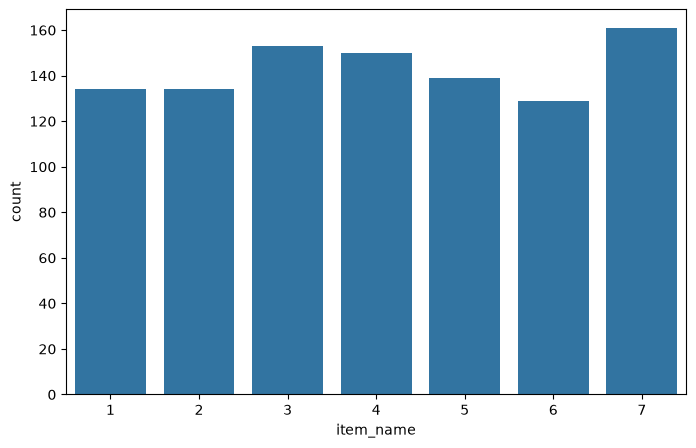

In [34]:
# Data Visualization
plt.figure(figsize = (8,5))
sns.countplot(data=df, x = 'item_name')
plt.show()

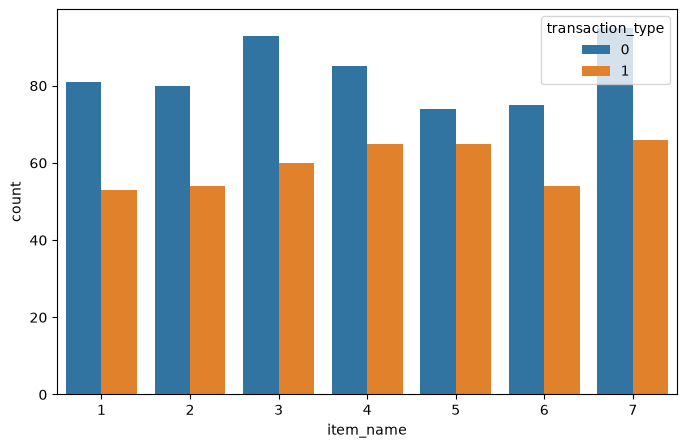

In [35]:
# Data Visualization
plt.figure(figsize = (8,5))
sns.countplot(data=df, x = 'item_name', hue='transaction_type')
plt.show()

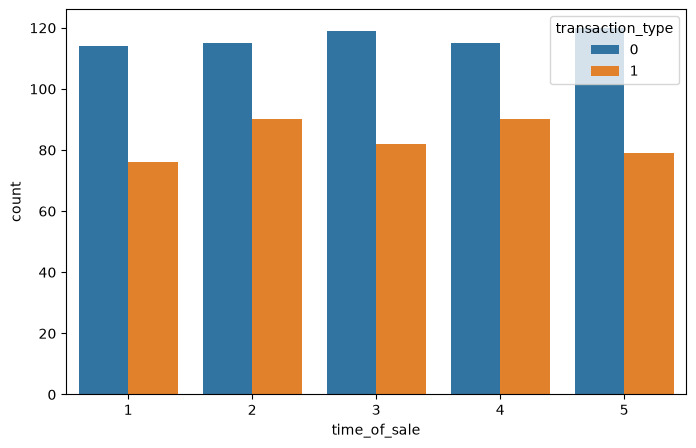

In [34]:
plt.figure(figsize = (8,5))
sns.countplot(data=df, x = 'time_of_sale', hue='transaction_type')
plt.show()

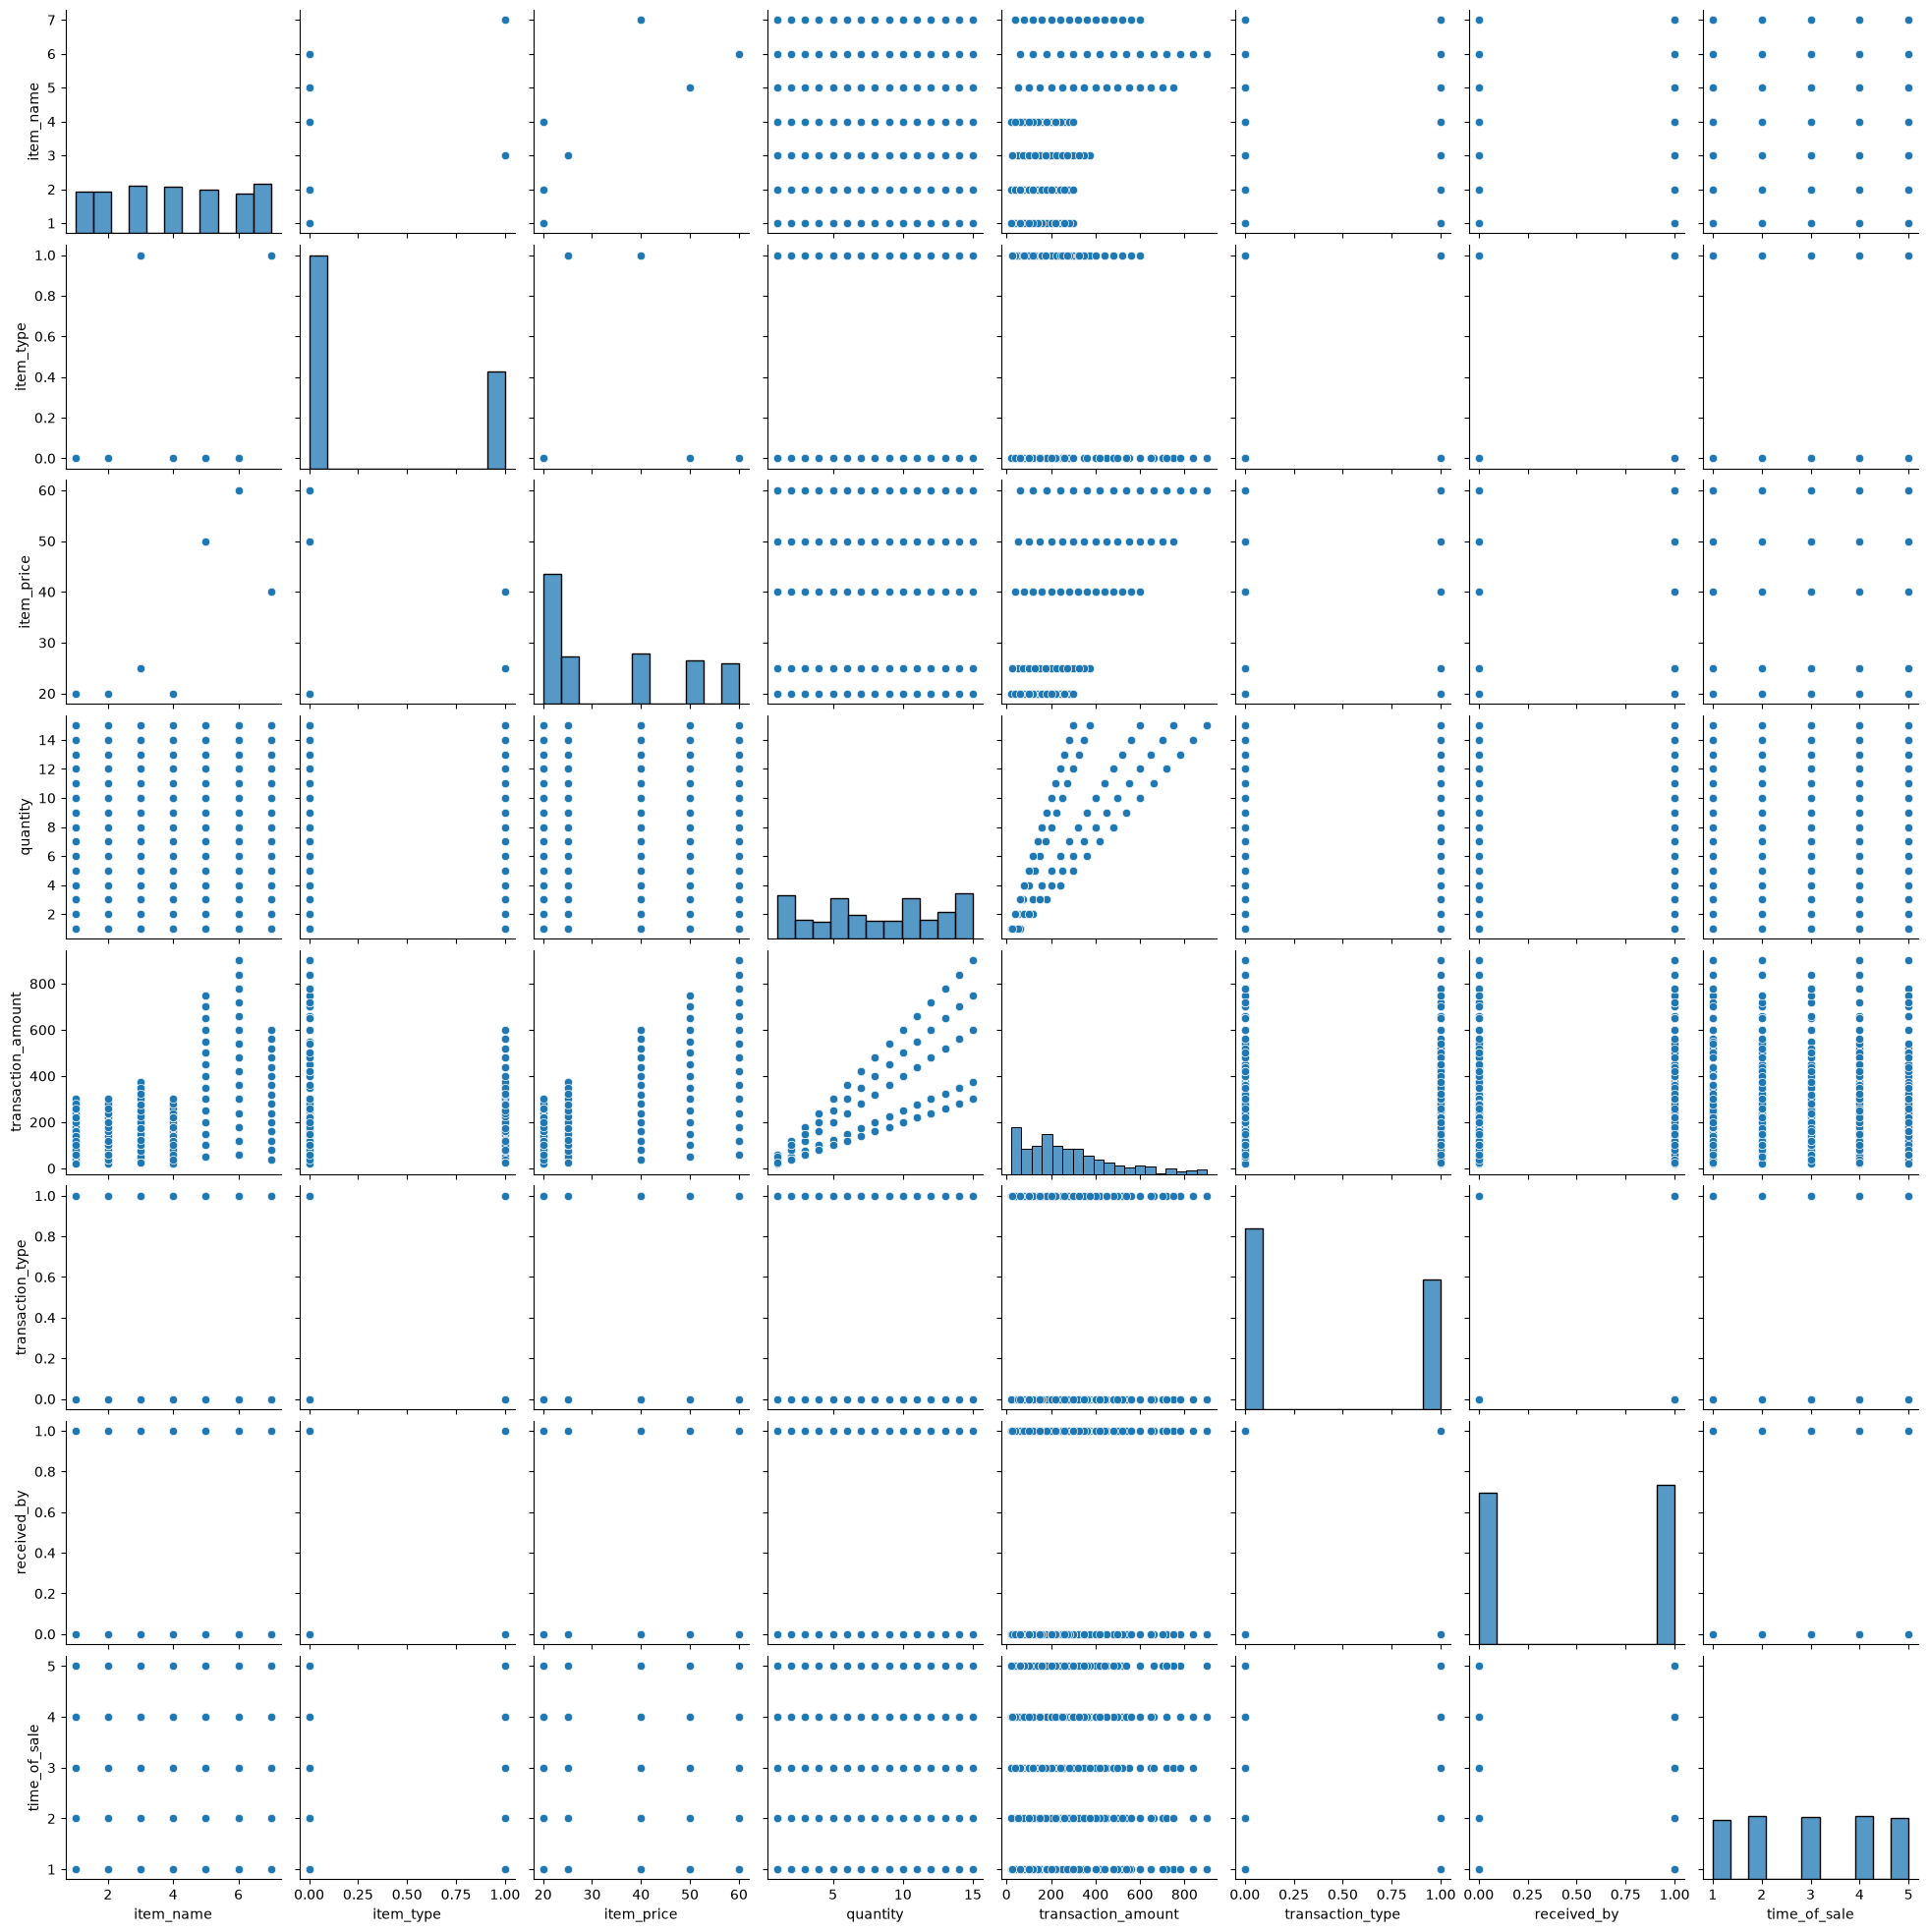

In [87]:
sns.pairplot(data = df)

In [ ]:
sns.scatterplot(data=df)
sns.kdeplot(data=df)
sns.barplot(data=df)
sns.boxplot(data=df)
sns.lineplot(data=df)
sns.pairplot(data=df)

In [88]:
df.to_csv('clean_sales.csv',index = False)

<Axes: >

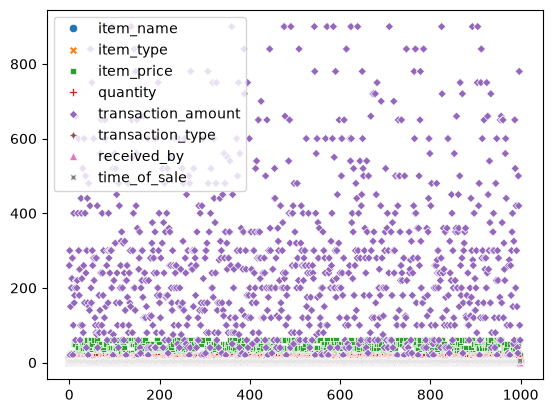

In [36]:
sns.scatterplot(data=df)

<Axes: ylabel='Density'>

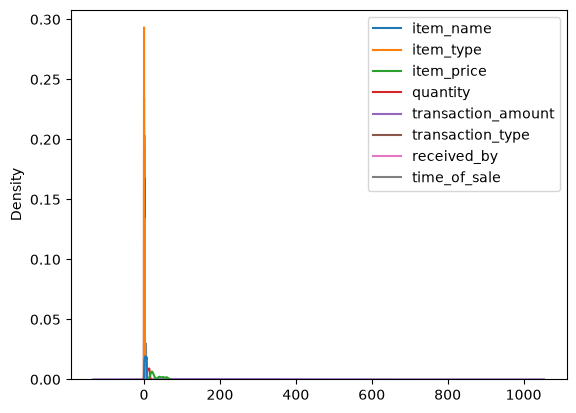

In [37]:
sns.kdeplot(data=df)

<Axes: >

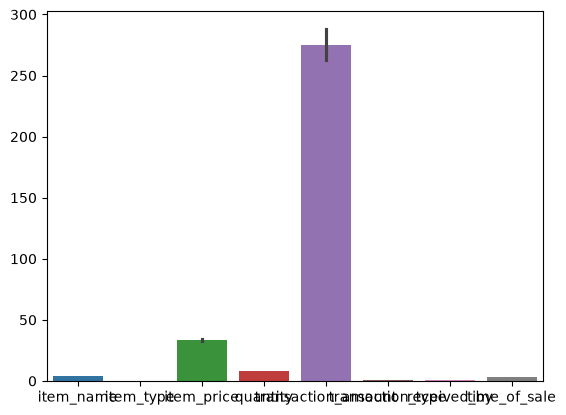

In [38]:
sns.barplot(data=df)

<Axes: >

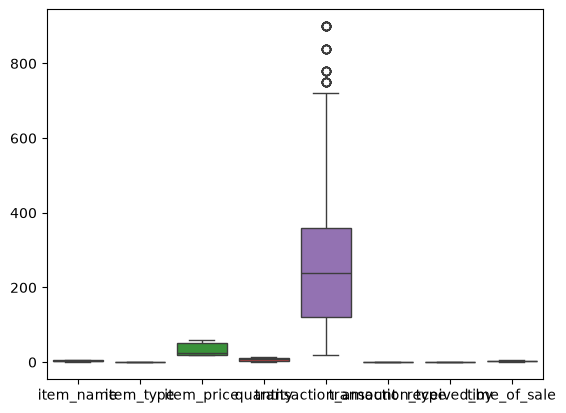

In [39]:
sns.boxplot(data=df)

<Axes: >

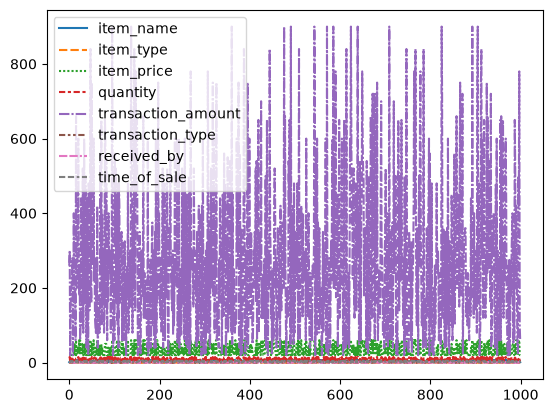

In [40]:
sns.lineplot(data=df)

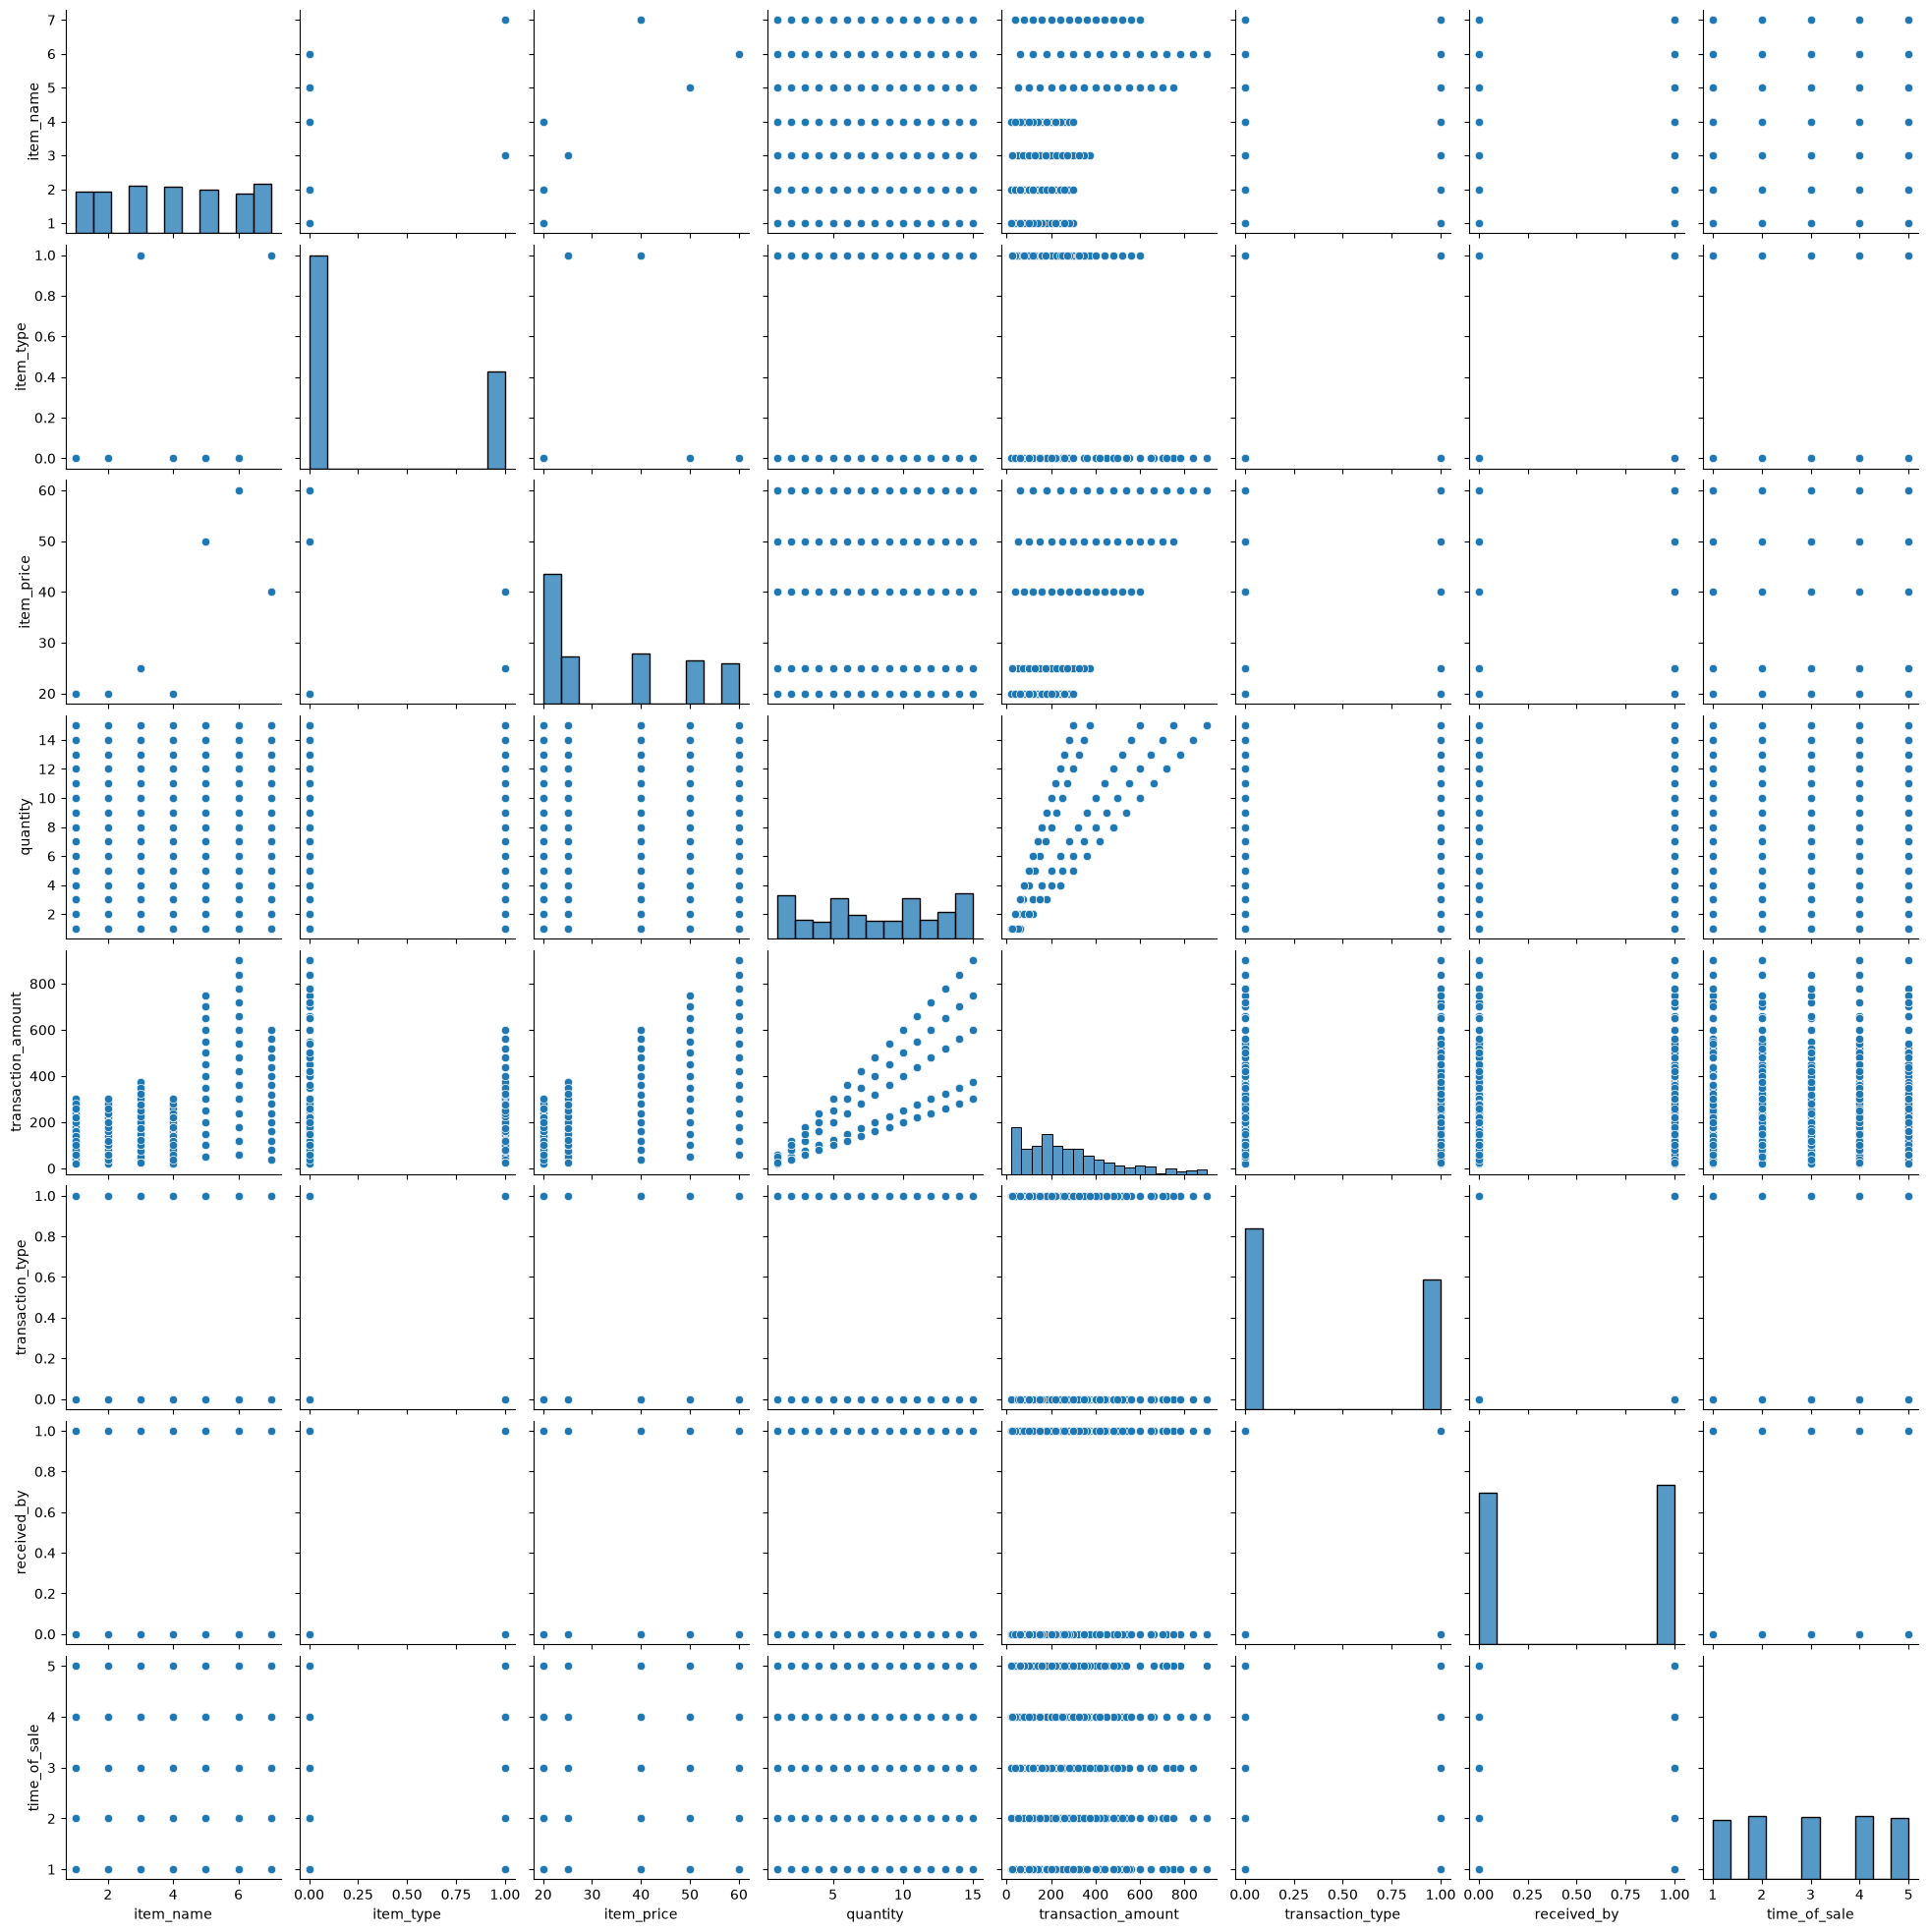

In [41]:
sns.pairplot(data=df)